# Технологии искусственного интеллекта. Анализ данных
## Лабораторная работа №4: Линейная регрессия
**Выполнил:** Мещеряков Сергей Евгеньевич  
**Группа:** 6401-01.03.02D

## 1. Загрузка и первичный анализ данных

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV, SelectKBest, f_regression

sns.set(style="whitegrid")
%matplotlib inline

In [35]:
data = pd.read_csv("global_emissions.csv")
data.head()

,Year,Country.Name,Country.Code,Country.GDP,Country.Population,Emissions.Production.CH4,Emissions.Production.N2O,Emissions.Production.CO2.Cement,Emissions.Production.CO2.Coal,Emissions.Production.CO2.Gas,Emissions.Production.CO2.Oil,Emissions.Production.CO2.Flaring,Emissions.Production.CO2.Other,Emissions.Production.CO2.Total,Emissions.Global Share.CO2.Cement,Emissions.Global Share.CO2.Coal,Emissions.Global Share.CO2.Gas,Emissions.Global Share.CO2.Oil,Emissions.Global Share.CO2.Flaring,Emissions.Global Share.CO2.Total
0,1992,Afghanistan,AFG,1.267754e+10,14485543,7.13,2.89,0.046,0.022,0.363,0.927,0.022,0.000000e+00,1.379,0.01,0.0,0.01,0.01,0.01,0.01
1,1993,Afghanistan,AFG,9.834581e+09,15816601,7.21,2.93,0.047,0.018,0.352,0.894,0.022,0.000000e+00,1.333,0.01,0.0,0.01,0.01,0.01,0.01
2,1994,Afghanistan,AFG,7.919857e+09,17075728,7.47,2.76,0.047,0.015,0.338,0.860,0.022,2.220446e-16,1.282,0.01,0.0,0.01,0.01,0.01,0.01
3,1995,Afghanistan,AFG,1.230753e+10,18110662,7.83,2.88,0.047,0.015,0.322,0.824,0.022,2.220446e-16,1.230,0.01,0.0,0.01,0.01,0.01,0.01
4,1996,Afghanistan,AFG,1.207013e+10,18853444,8.67,3.12,0.047,0.007,0.308,0.780,0.022,1.000000e-03,1.165,0.01,0.0,0.01,0.01,0.01,0.00


### Описание датасета

Датасет содержит данные о выбросах парниковых газов по странам за разные годы. Источник: файл `global_emissions.csv`.

**Целевой признак:** `Emissions.Production.CO2.Total` – суммарные выбросы CO₂.

**Признаки после удаления прямых компонент выбросов CO₂:**
- `Year` – год наблюдения
- `Country.Name` – название страны (категориальный)
- `Country.Code` – код страны (категориальный)
- `Country.GDP` – ВВП страны
- `Country.Population` – численность населения
- `Emissions.Production.CH4` – выбросы метана
- `Emissions.Production.N2O` – выбросы закиси азота
- `Emissions.Global Share.CO2.Cement` – доля глобальных выбросов CO₂ (цемент)
- `Emissions.Global Share.CO2.Coal` – доля глобальных выбросов CO₂ (уголь)
- `Emissions.Global Share.CO2.Gas` – доля глобальных выбросов CO₂ (газ)
- `Emissions.Global Share.CO2.Oil` – доля глобальных выбросов CO₂ (нефть)
- `Emissions.Global Share.CO2.Flaring` – доля глобальных выбросов CO₂ (факельное сжигание)
- `Emissions.Global Share.CO2.Other` – доля глобальных выбросов CO₂ (прочее)
- `Emissions.Global Share.CO2.Total` – общая доля в глобальных выбросах CO₂

Исключены все столбцы, начинающиеся с `Emissions.Production.CO2.` (кроме целевого).

In [36]:
target = 'Emissions.Production.CO2.Total'
co2_component_cols = [col for col in data.columns if col.startswith('Emissions.Production.CO2.') and col != target]
print(f"Удаляемые компоненты CO₂: {co2_component_cols}")

data_clean = data.dropna().copy()
data_clean = data_clean.drop(columns=co2_component_cols)

print(f"Размер после удаления пропусков и компонент CO₂: {data_clean.shape}")

Удаляемые компоненты CO₂: ['Emissions.Production.CO2.Cement', 'Emissions.Production.CO2.Coal', 'Emissions.Production.CO2.Gas', 'Emissions.Production.CO2.Oil', 'Emissions.Production.CO2.Flaring', 'Emissions.Production.CO2.Other']
Размер после удаления пропусков и компонент CO₂: (2484, 14)


## 2. Этап 1: Подготовка данных без категориальных признаков

In [37]:
categorical_cols = ['Country.Name', 'Country.Code']
numeric_cols = data_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove(target)

X_num = data_clean[numeric_cols]
y = data_clean[target]

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_num_scaled, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка (числовые): {X_train_num.shape}")
print(f"Тестовая выборка (числовые): {X_test_num.shape}")

Обучающая выборка (числовые): (1987, 11)
Тестовая выборка (числовые): (497, 11)


### 2.1 Визуализация корреляционной матрицы (heatmap)

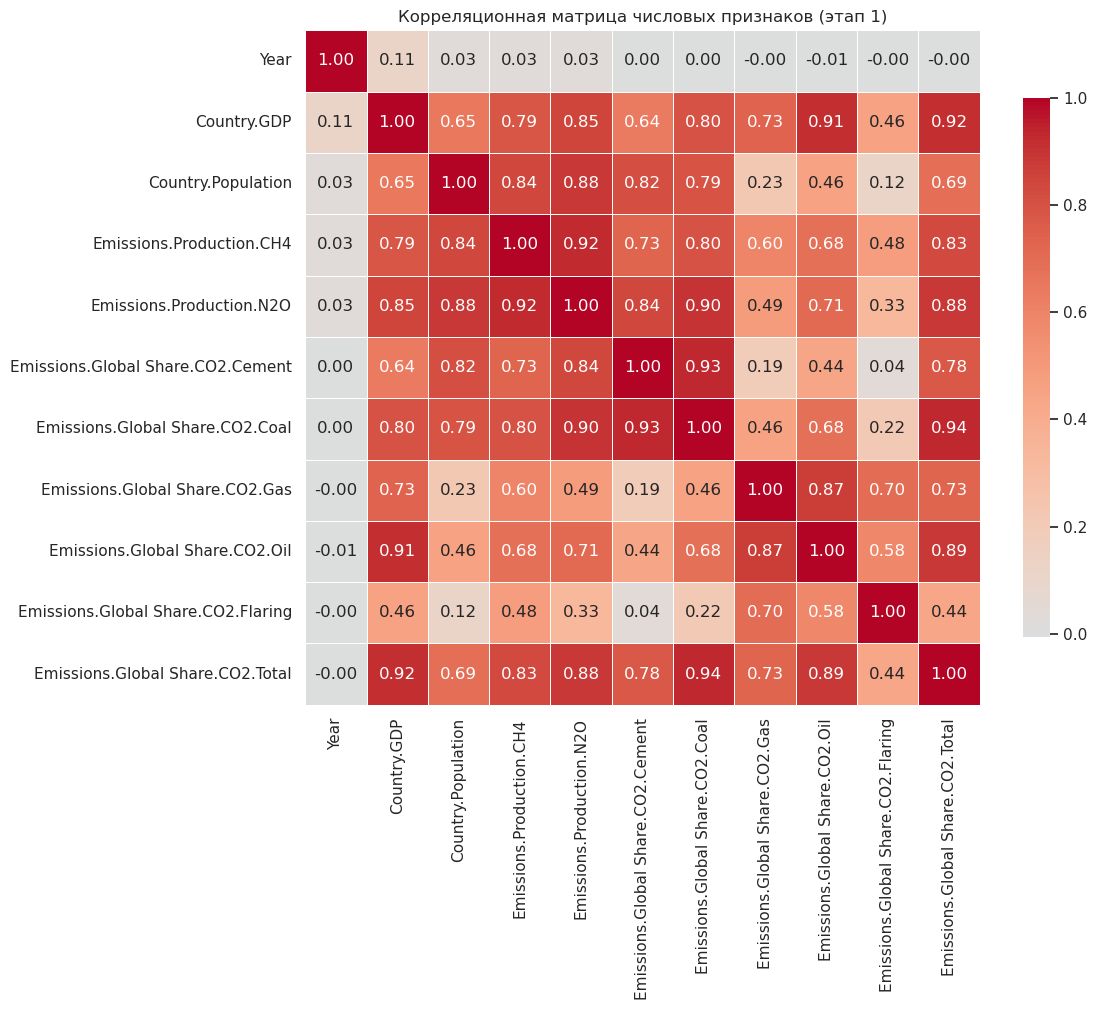

In [38]:
corr_matrix = pd.DataFrame(X_num_scaled, columns=numeric_cols).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица числовых признаков (этап 1)')
plt.tight_layout()
plt.show()

### 2.2 Визуализация взаимосвязи target с каждым признаком

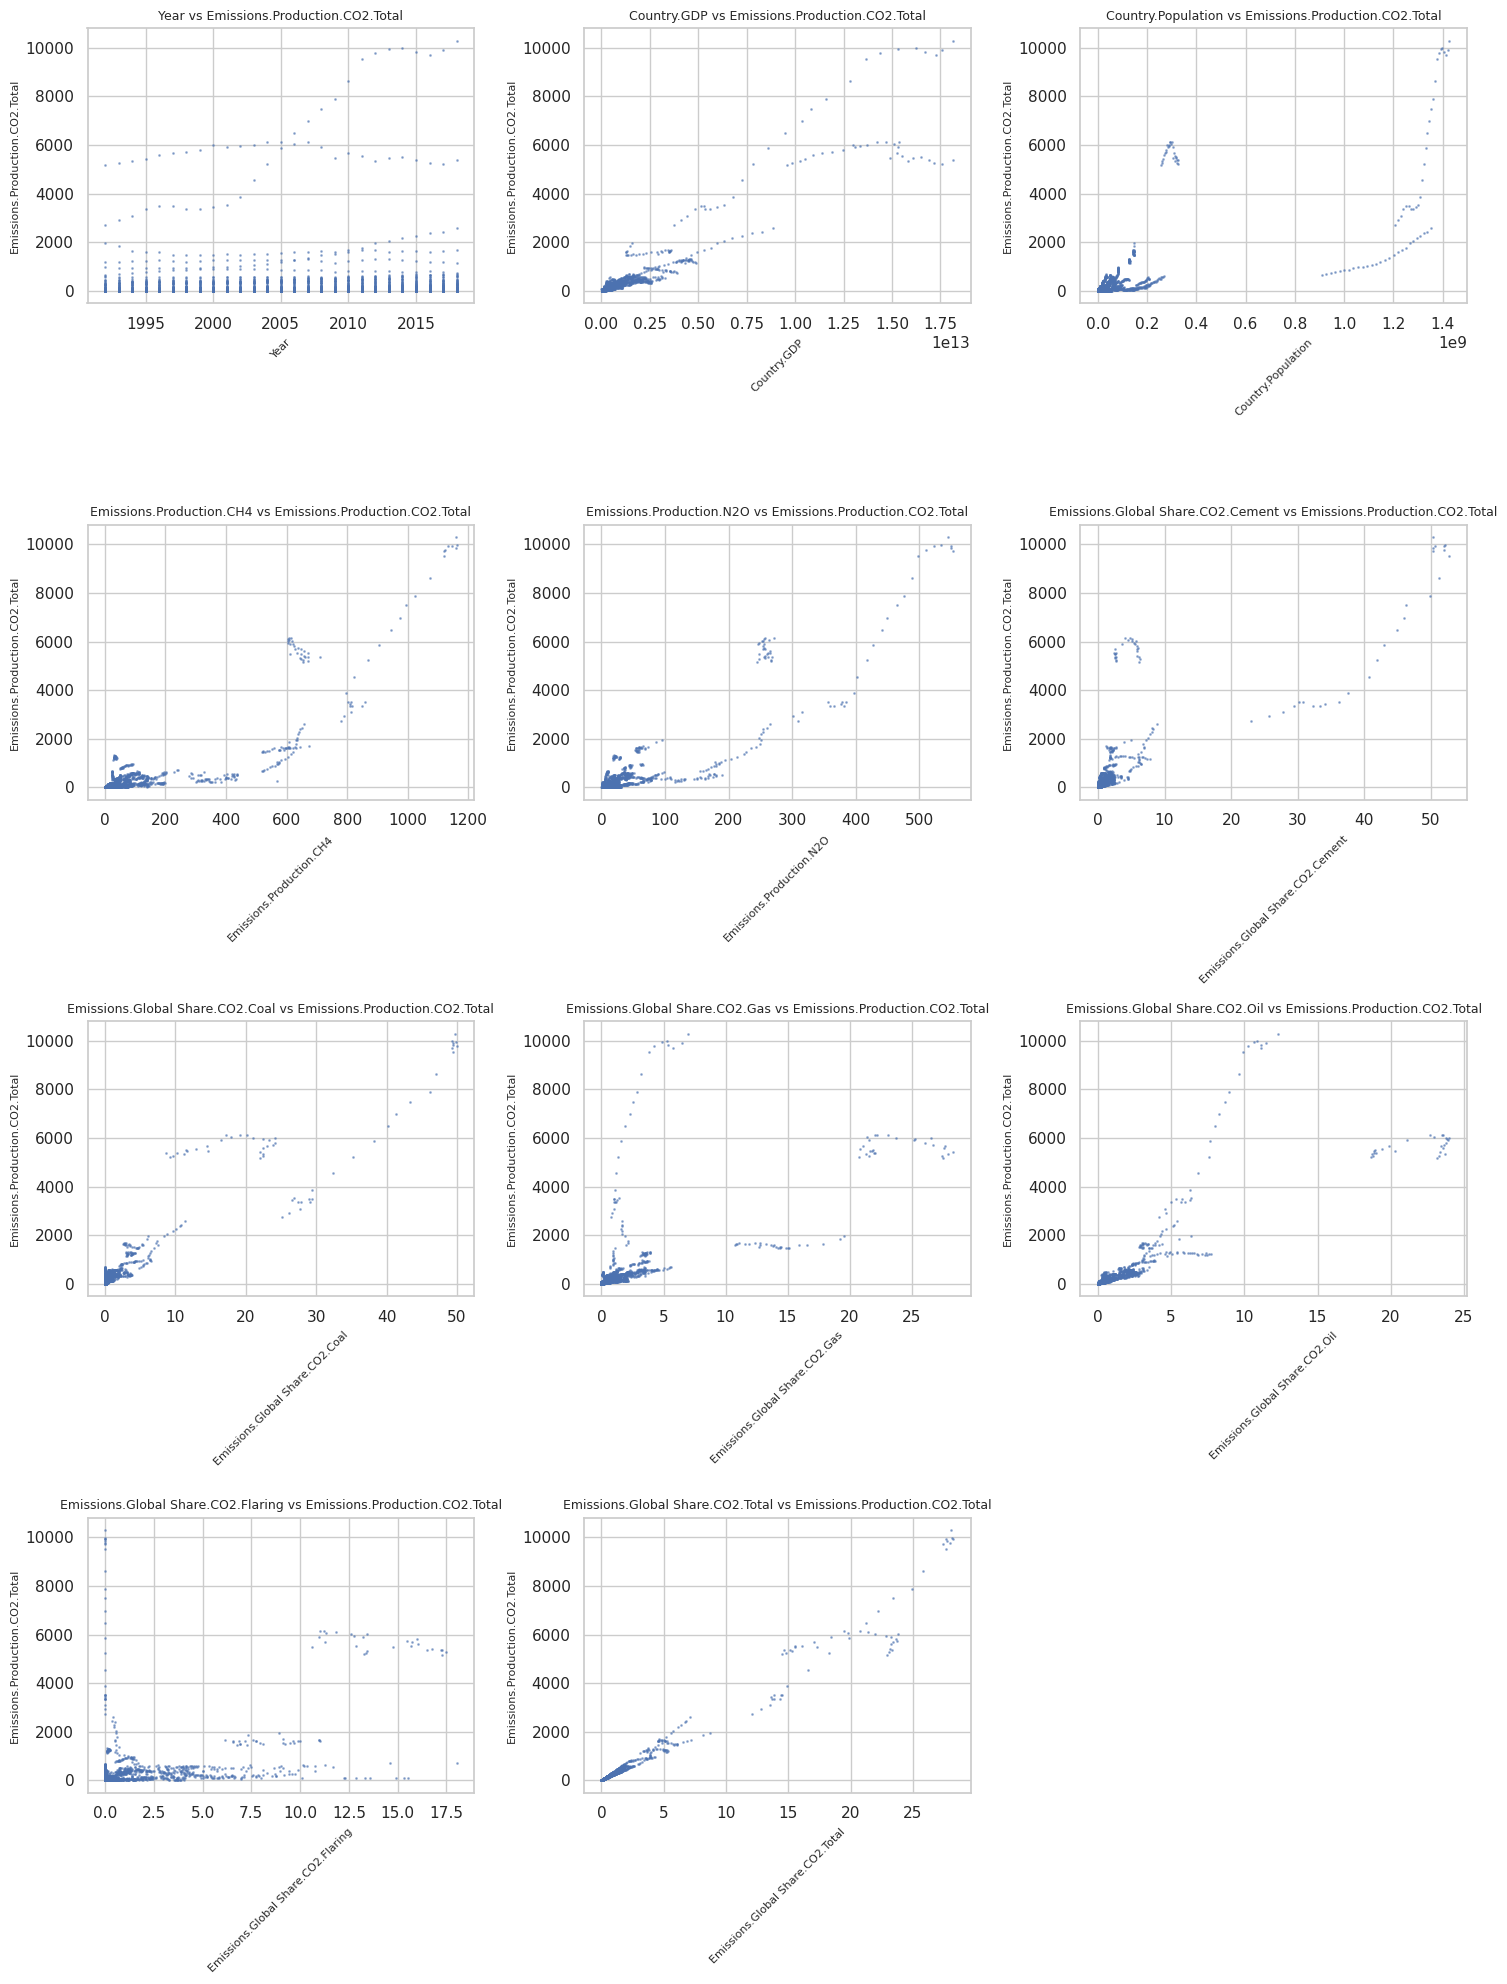

In [39]:
fig, axes = plt.subplots(4, 3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        axes[i].scatter(X_num[col], y, alpha=0.5, s=1)
        axes[i].set_xlabel(col, rotation=45, fontsize=8)
        axes[i].set_ylabel(target, fontsize=8)
        axes[i].set_title(f'{col} vs {target}', fontsize=9)

for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Регрессия МНК (LinearRegression) на этапе 1

In [40]:
lr = LinearRegression()
lr.fit(X_train_num, y_train)
y_pred_lr = lr.predict(X_test_num)

print("LinearRegression (этап 1):")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"R²: {r2_score(y_test, y_pred_lr):.4f}")
print(f"\nIntercept: {lr.intercept_:.4f}")
print(f"Коэффициенты: {dict(zip(numeric_cols, lr.coef_))}")

LinearRegression (этап 1):
MSE: 3382.6664
MAE: 32.5039
R²: 0.9966

Intercept: 299.8743
Коэффициенты: {'Year': np.float64(0.3114996747816856), 'Country.GDP': np.float64(426.49683041147244), 'Country.Population': np.float64(-63.2436283429939), 'Emissions.Production.CH4': np.float64(59.714602811924514), 'Emissions.Production.N2O': np.float64(-66.27857962513929), 'Emissions.Global Share.CO2.Cement': np.float64(-81.45780073762208), 'Emissions.Global Share.CO2.Coal': np.float64(-797.3275721503691), 'Emissions.Global Share.CO2.Gas': np.float64(-279.82937770607197), 'Emissions.Global Share.CO2.Oil': np.float64(-696.7434535529742), 'Emissions.Global Share.CO2.Flaring': np.float64(-4.495380233836499), 'Emissions.Global Share.CO2.Total': np.float64(2220.648938146666)}


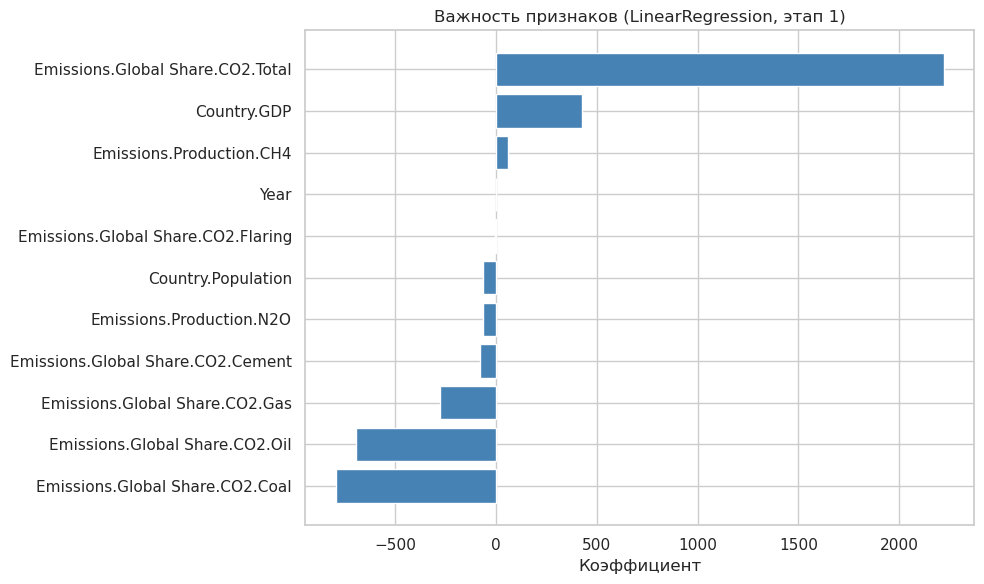

In [41]:
coef_lr = pd.DataFrame({'feature': numeric_cols, 'coefficient': lr.coef_})\
          .sort_values('coefficient', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(coef_lr['feature'], coef_lr['coefficient'], color='steelblue')
plt.xlabel('Коэффициент')
plt.title('Важность признаков (LinearRegression, этап 1)')
plt.tight_layout()
plt.show()

## 4. Другие модели регрессии на этапе 1

### 4.1 Ridge регрессия

In [42]:
ridge = Ridge(random_state=42)
param_ridge = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
grid_ridge = GridSearchCV(ridge, param_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train_num, y_train)

best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_num)

print("Ridge (этап 1):")
print(f"Лучшие параметры: {grid_ridge.best_params_}")
print(f"Лучшее CV R²: {grid_ridge.best_score_:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_ridge):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge):.4f}")
print(f"R²: {r2_score(y_test, y_pred_ridge):.4f}")

Ridge (этап 1):
Лучшие параметры: {'alpha': 0.01}
Лучшее CV R²: 0.9948
MSE: 3382.7657
MAE: 32.5263
R²: 0.9966


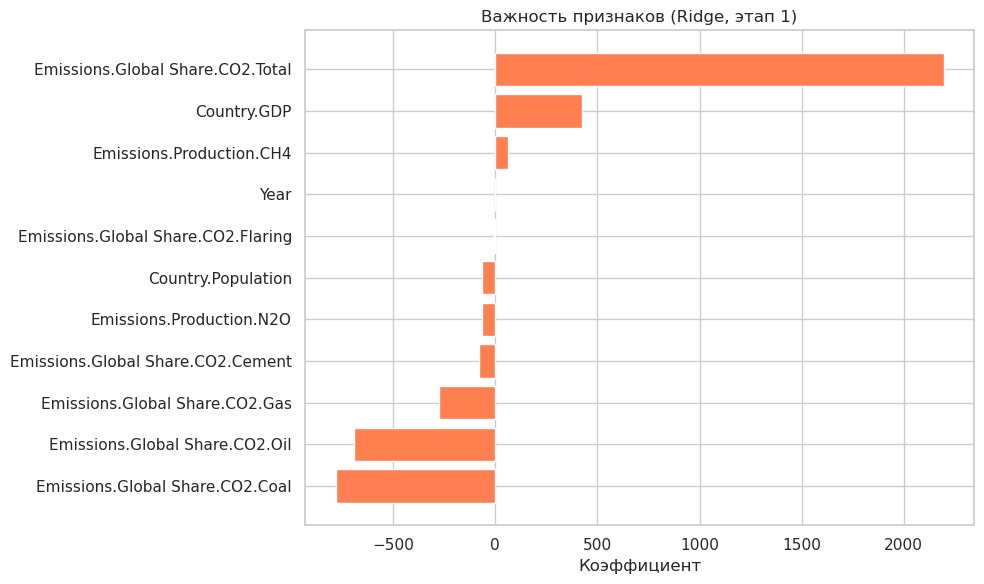

In [43]:
coef_ridge = pd.DataFrame({'feature': numeric_cols, 'coefficient': best_ridge.coef_})\
             .sort_values('coefficient', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(coef_ridge['feature'], coef_ridge['coefficient'], color='coral')
plt.xlabel('Коэффициент')
plt.title('Важность признаков (Ridge, этап 1)')
plt.tight_layout()
plt.show()

### 4.2 LASSO регрессия

In [44]:
lasso = Lasso(random_state=42, max_iter=10000)
param_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_lasso = GridSearchCV(lasso, param_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train_num, y_train)

best_lasso = grid_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_num)

print("LASSO (этап 1):")
print(f"Лучшие параметры: {grid_lasso.best_params_}")
print(f"Лучшее CV R²: {grid_lasso.best_score_:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lasso):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso):.4f}")
print(f"R²: {r2_score(y_test, y_pred_lasso):.4f}")

/home/flowersinvase/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.099e+05, tolerance: 1.258e+05
  model = cd_fast.enet_coordinate_descent(
/home/flowersinvase/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.011e+05, tolerance: 1.390e+05
  model = cd_fast.enet_coordinate_descent(
/home/flowersinvase/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing 

LASSO (этап 1):
Лучшие параметры: {'alpha': 0.01}
Лучшее CV R²: 0.9948
MSE: 3381.9680
MAE: 32.5229
R²: 0.9966


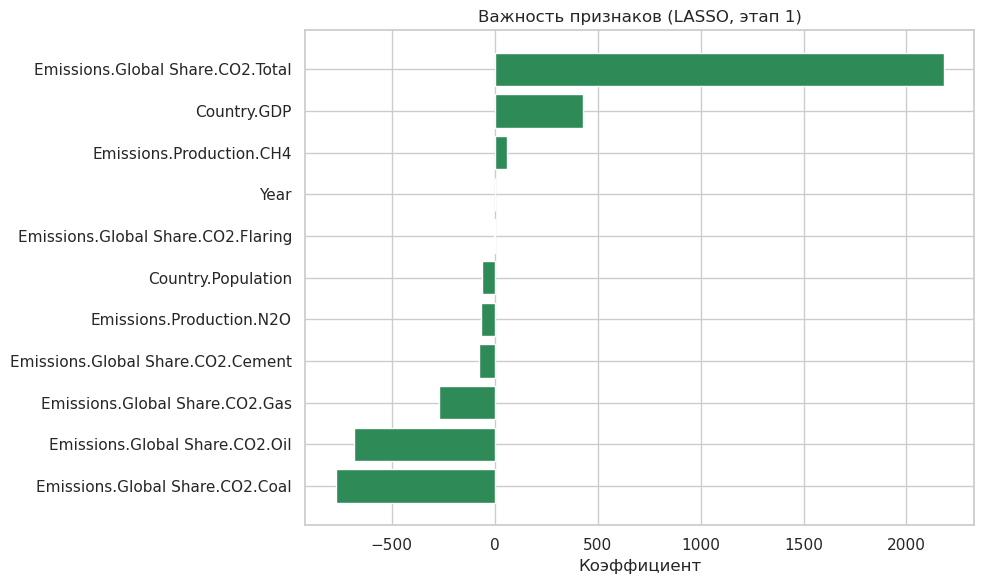

In [45]:
coef_lasso = pd.DataFrame({'feature': numeric_cols, 'coefficient': best_lasso.coef_})\
              .sort_values('coefficient', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(coef_lasso['feature'], coef_lasso['coefficient'], color='seagreen')
plt.xlabel('Коэффициент')
plt.title('Важность признаков (LASSO, этап 1)')
plt.tight_layout()
plt.show()

### 4.3 Elastic Net

In [46]:
elastic = ElasticNet(random_state=42, max_iter=10000)
param_elastic = {'alpha': [0.01, 0.1, 1, 10], 'l1_ratio': [0.1, 0.5, 0.7, 0.9, 1.0]}
grid_elastic = GridSearchCV(elastic, param_elastic, cv=5, scoring='r2')
grid_elastic.fit(X_train_num, y_train)

best_elastic = grid_elastic.best_estimator_
y_pred_elastic = best_elastic.predict(X_test_num)

print("ElasticNet (этап 1):")
print(f"Лучшие параметры: {grid_elastic.best_params_}")
print(f"Лучшее CV R²: {grid_elastic.best_score_:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_elastic):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_elastic):.4f}")
print(f"R²: {r2_score(y_test, y_pred_elastic):.4f}")

ElasticNet (этап 1):
Лучшие параметры: {'alpha': 0.01, 'l1_ratio': 1.0}
Лучшее CV R²: 0.9948
MSE: 3381.9680
MAE: 32.5229
R²: 0.9966


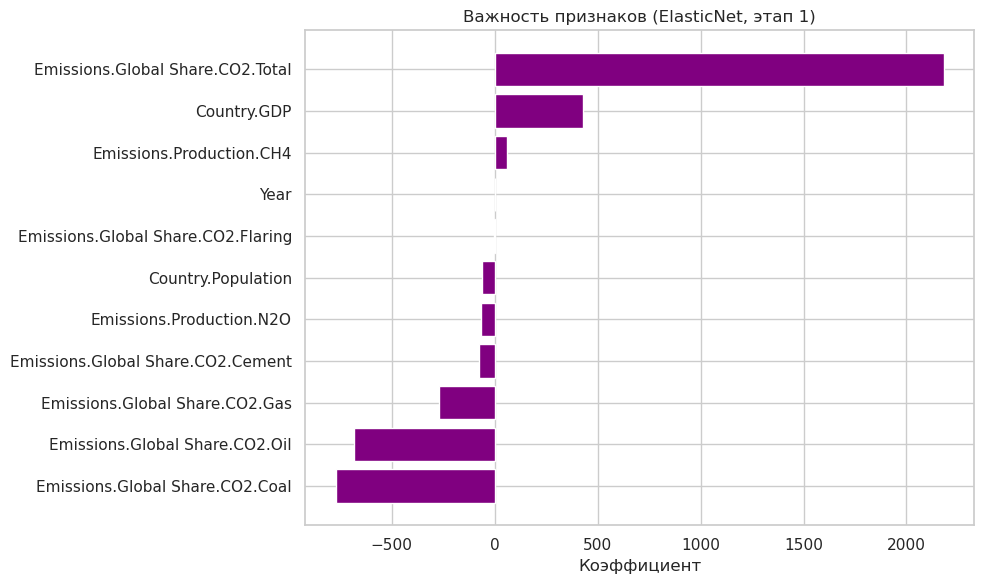

In [47]:
coef_elastic = pd.DataFrame({'feature': numeric_cols, 'coefficient': best_elastic.coef_})\
                .sort_values('coefficient', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(coef_elastic['feature'], coef_elastic['coefficient'], color='purple')
plt.xlabel('Коэффициент')
plt.title('Важность признаков (ElasticNet, этап 1)')
plt.tight_layout()
plt.show()

### 4.4 KNeighborsRegressor

In [48]:
knn = KNeighborsRegressor()
param_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15, 20]}
grid_knn = GridSearchCV(knn, param_knn, cv=5, scoring='r2')
grid_knn.fit(X_train_num, y_train)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_num)

print("KNeighborsRegressor (этап 1):")
print(f"Лучшие параметры: {grid_knn.best_params_}")
print(f"Лучшее CV R²: {grid_knn.best_score_:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_knn):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_knn):.4f}")
print(f"R²: {r2_score(y_test, y_pred_knn):.4f}")

KNeighborsRegressor (этап 1):
Лучшие параметры: {'n_neighbors': 3}
Лучшее CV R²: 0.9976
MSE: 1053.4966
MAE: 13.2853
R²: 0.9990


### 4.5 DecisionTreeRegressor

In [49]:
dt = DecisionTreeRegressor(random_state=42)
param_dt = {'max_depth': [3, 5, 7, 10, 15, None]}
grid_dt = GridSearchCV(dt, param_dt, cv=5, scoring='r2')
grid_dt.fit(X_train_num, y_train)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_num)

print("DecisionTreeRegressor (этап 1):")
print(f"Лучшие параметры: {grid_dt.best_params_}")
print(f"Лучшее CV R²: {grid_dt.best_score_:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_dt):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_dt):.4f}")
print(f"R²: {r2_score(y_test, y_pred_dt):.4f}")

DecisionTreeRegressor (этап 1):
Лучшие параметры: {'max_depth': 15}
Лучшее CV R²: 0.9965
MSE: 5877.9776
MAE: 13.9728
R²: 0.9941


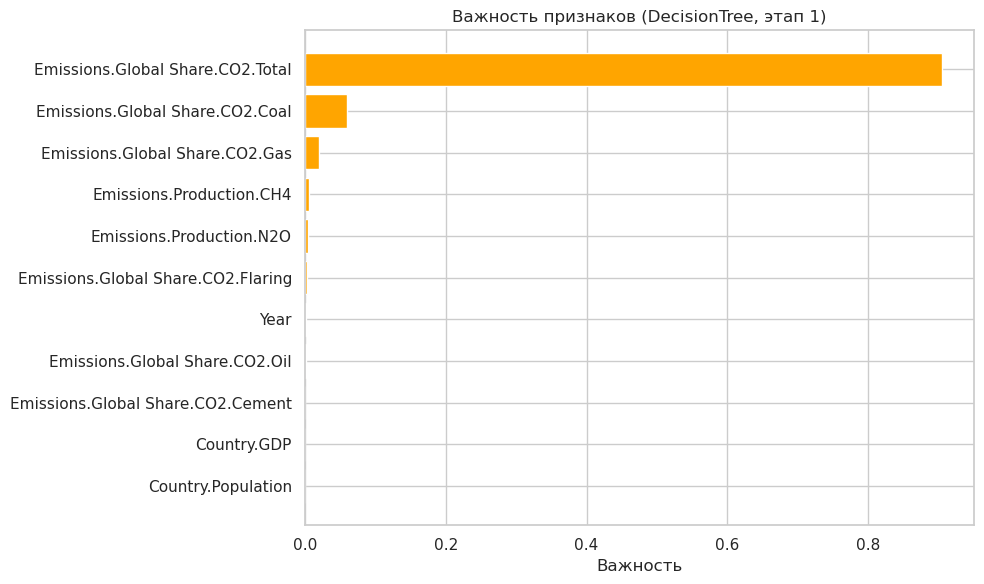

In [50]:
imp_dt = pd.DataFrame({'feature': numeric_cols, 'importance': best_dt.feature_importances_})\
         .sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(imp_dt['feature'], imp_dt['importance'], color='orange')
plt.xlabel('Важность')
plt.title('Важность признаков (DecisionTree, этап 1)')
plt.tight_layout()
plt.show()

### 4.6 RandomForestRegressor

In [51]:
rf = RandomForestRegressor(random_state=42)
param_rf = {'max_depth': [5, 10, 15], 'n_estimators': [50, 100]}
grid_rf = GridSearchCV(rf, param_rf, cv=5, scoring='r2')
grid_rf.fit(X_train_num, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_num)

print("RandomForestRegressor (этап 1):")
print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Лучшее CV R²: {grid_rf.best_score_:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"R²: {r2_score(y_test, y_pred_rf):.4f}")

RandomForestRegressor (этап 1):
Лучшие параметры: {'max_depth': 15, 'n_estimators': 100}
Лучшее CV R²: 0.9987
MSE: 1125.4137
MAE: 7.3700
R²: 0.9989


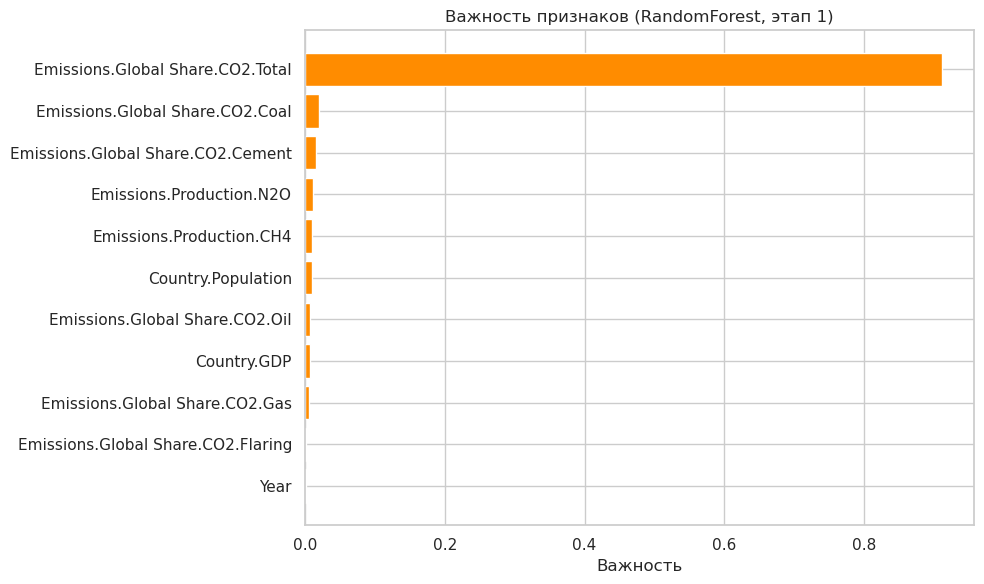

In [52]:
imp_rf = pd.DataFrame({'feature': numeric_cols, 'importance': best_rf.feature_importances_})\
         .sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(imp_rf['feature'], imp_rf['importance'], color='darkorange')
plt.xlabel('Важность')
plt.title('Важность признаков (RandomForest, этап 1)')
plt.tight_layout()
plt.show()

**Сравнение моделей на этапе 1:**

Вариации линейной регрессии показали одинаковые результаты. У KNN метрики лучше, чем у деревьев

## 5. Этап 2: Подготовка данных с категориальными признаками

In [53]:
X_full = data_clean.drop(target, axis=1)
y_full = data_clean[target]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_full_processed = preprocessor.fit_transform(X_full)
feature_names_full = numeric_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full_processed, y_full, test_size=0.2, random_state=42
)

print(f"Обучающая выборка (с категориальными): {X_train_full.shape}")
print(f"Тестовая выборка (с категориальными): {X_test_full.shape}")

Обучающая выборка (с категориальными): (1987, 195)
Тестовая выборка (с категориальными): (497, 195)


## 6. Обучение моделей на этапе 2 (с категориальными признаками)

### 6.1 LinearRegression

In [54]:
lr_full = LinearRegression()
lr_full.fit(X_train_full, y_train_full)
y_pred_lr_full = lr_full.predict(X_test_full)

print("LinearRegression (этап 2):")
print(f"MSE: {mean_squared_error(y_test_full, y_pred_lr_full):.4f}")
print(f"MAE: {mean_absolute_error(y_test_full, y_pred_lr_full):.4f}")
print(f"R²: {r2_score(y_test_full, y_pred_lr_full):.4f}")

LinearRegression (этап 2):
MSE: 755.5260
MAE: 14.4165
R²: 0.9992


### 6.2 Ridge (с лучшим alpha из этапа 1)

In [55]:
ridge_full = Ridge(alpha=grid_ridge.best_params_['alpha'], random_state=42)
ridge_full.fit(X_train_full, y_train_full)
y_pred_ridge_full = ridge_full.predict(X_test_full)

print("Ridge (этап 2):")
print(f"MSE: {mean_squared_error(y_test_full, y_pred_ridge_full):.4f}")
print(f"MAE: {mean_absolute_error(y_test_full, y_pred_ridge_full):.4f}")
print(f"R²: {r2_score(y_test_full, y_pred_ridge_full):.4f}")

Ridge (этап 2):
MSE: 766.5491
MAE: 14.4619
R²: 0.9992


### 6.3 LASSO (с лучшим alpha)

In [56]:
lasso_full = Lasso(alpha=grid_lasso.best_params_['alpha'], random_state=42, max_iter=10000)
lasso_full.fit(X_train_full, y_train_full)
y_pred_lasso_full = lasso_full.predict(X_test_full)

print("LASSO (этап 2):")
print(f"MSE: {mean_squared_error(y_test_full, y_pred_lasso_full):.4f}")
print(f"MAE: {mean_absolute_error(y_test_full, y_pred_lasso_full):.4f}")
print(f"R²: {r2_score(y_test_full, y_pred_lasso_full):.4f}")

LASSO (этап 2):
MSE: 817.7837
MAE: 14.5819
R²: 0.9992


/home/flowersinvase/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.733e+05, tolerance: 1.695e+05
  model = cd_fast.enet_coordinate_descent(


### 6.4 Elastic Net (с лучшими параметрами)

In [57]:
elastic_full = ElasticNet(alpha=grid_elastic.best_params_['alpha'],
                          l1_ratio=grid_elastic.best_params_['l1_ratio'],
                          random_state=42, max_iter=10000)
elastic_full.fit(X_train_full, y_train_full)
y_pred_elastic_full = elastic_full.predict(X_test_full)

print("ElasticNet (этап 2):")
print(f"MSE: {mean_squared_error(y_test_full, y_pred_elastic_full):.4f}")
print(f"MAE: {mean_absolute_error(y_test_full, y_pred_elastic_full):.4f}")
print(f"R²: {r2_score(y_test_full, y_pred_elastic_full):.4f}")

ElasticNet (этап 2):
MSE: 817.7837
MAE: 14.5819
R²: 0.9992


/home/flowersinvase/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.733e+05, tolerance: 1.695e+05
  model = cd_fast.enet_coordinate_descent(


### 6.5 KNeighborsRegressor (с лучшим n_neighbors)

In [58]:
knn_full = KNeighborsRegressor(n_neighbors=grid_knn.best_params_['n_neighbors'])
knn_full.fit(X_train_full, y_train_full)
y_pred_knn_full = knn_full.predict(X_test_full)

print("KNeighborsRegressor (этап 2):")
print(f"MSE: {mean_squared_error(y_test_full, y_pred_knn_full):.4f}")
print(f"MAE: {mean_absolute_error(y_test_full, y_pred_knn_full):.4f}")
print(f"R²: {r2_score(y_test_full, y_pred_knn_full):.4f}")

KNeighborsRegressor (этап 2):
MSE: 968.2346
MAE: 9.2887
R²: 0.9990


### 6.6 DecisionTreeRegressor (с лучшим max_depth)

In [59]:
dt_full = DecisionTreeRegressor(max_depth=grid_dt.best_params_['max_depth'], random_state=42)
dt_full.fit(X_train_full, y_train_full)
y_pred_dt_full = dt_full.predict(X_test_full)

print("DecisionTreeRegressor (этап 2):")
print(f"MSE: {mean_squared_error(y_test_full, y_pred_dt_full):.4f}")
print(f"MAE: {mean_absolute_error(y_test_full, y_pred_dt_full):.4f}")
print(f"R²: {r2_score(y_test_full, y_pred_dt_full):.4f}")

DecisionTreeRegressor (этап 2):
MSE: 2994.8411
MAE: 12.4616
R²: 0.9970


### 6.7 RandomForestRegressor (с лучшими параметрами)

In [60]:
rf_full = RandomForestRegressor(max_depth=grid_rf.best_params_['max_depth'],
                                n_estimators=grid_rf.best_params_['n_estimators'],
                                random_state=42)
rf_full.fit(X_train_full, y_train_full)
y_pred_rf_full = rf_full.predict(X_test_full)

print("RandomForestRegressor (этап 2):")
print(f"MSE: {mean_squared_error(y_test_full, y_pred_rf_full):.4f}")
print(f"MAE: {mean_absolute_error(y_test_full, y_pred_rf_full):.4f}")
print(f"R²: {r2_score(y_test_full, y_pred_rf_full):.4f}")

RandomForestRegressor (этап 2):
MSE: 1204.6057
MAE: 7.4040
R²: 0.9988


**Сравнение метрик этапов 1 и 2:**

Добавление категориальных признаков улучшило качество всех моделей. Тенденция с KNN и деревьями - лучшие метрики у KNN - сохраняется

### 6.8 Лучшая модель на этапе 2 и визуализация важности признаков

In [61]:
best_model_full = lr_full
best_model_name = "LinearRegression"
best_r2_full = r2_score(y_test_full, y_pred_lr_full)
print(f"Лучшая модель: {best_model_name} с R² = {best_r2_full:.4f}")

Лучшая модель: LinearRegression с R² = 0.9992


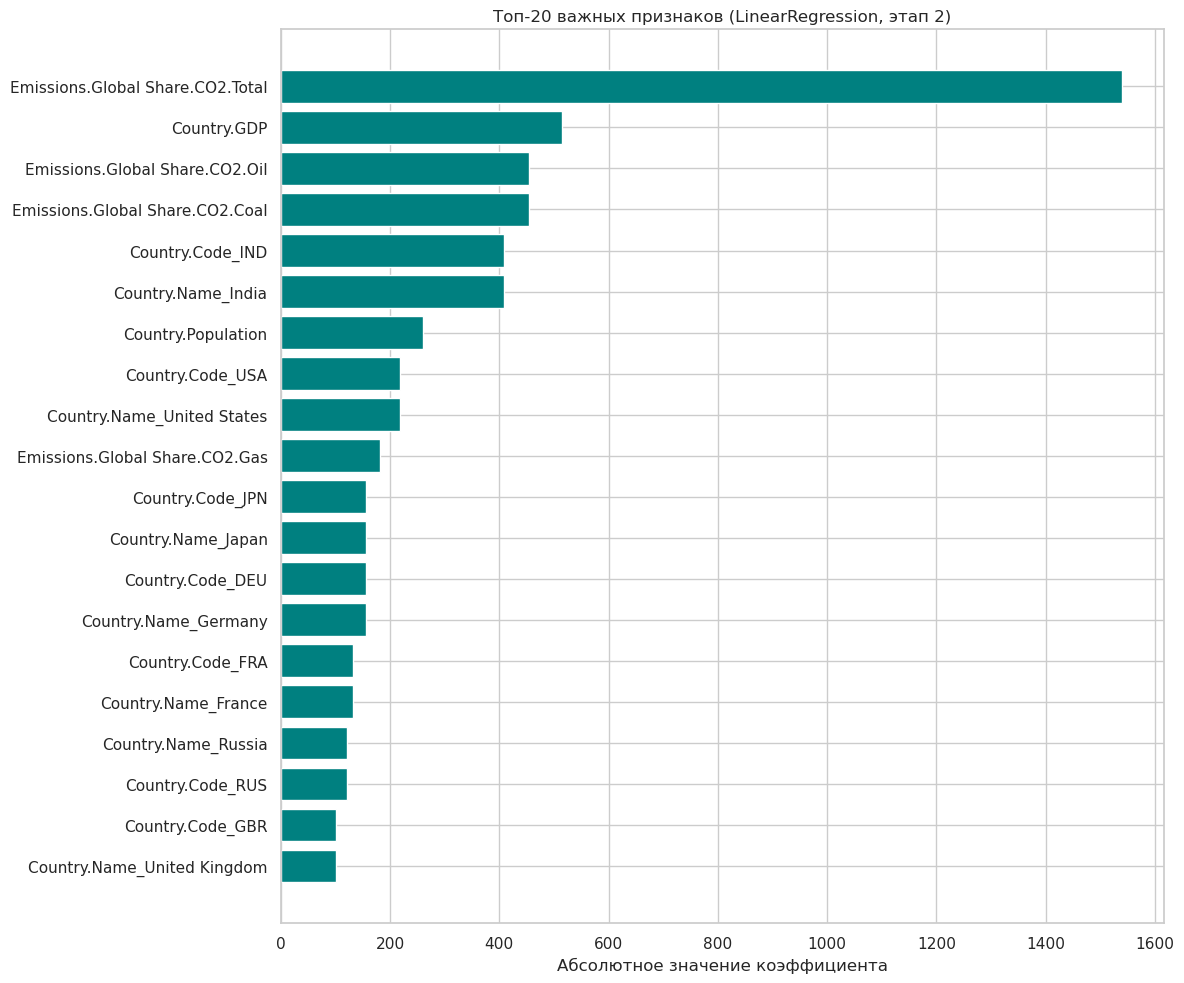

In [62]:
coef_lr_full = lr_full.coef_
imp_df_lr = pd.DataFrame({'feature': feature_names_full, 'importance': np.abs(coef_lr_full)})\
           .sort_values('importance', ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(imp_df_lr['feature'][-20:], imp_df_lr['importance'][-20:], color='teal')
plt.xlabel('Абсолютное значение коэффициента')
plt.title('Топ-20 важных признаков (LinearRegression, этап 2)')
plt.tight_layout()
plt.show()

## 7. Фильтрация признаков

### 7.1 RFECV (Recursive Feature Elimination with Cross-Validation)

In [63]:
lr_estimator = LinearRegression()
rfecv = RFECV(lr_estimator, cv=5, scoring='r2', min_features_to_select=5)
rfecv.fit(X_train_full, y_train_full)

print(f"Оптимальное количество признаков (RFECV): {rfecv.n_features_}")

selected_rfecv = [feature_names_full[i] for i in range(len(feature_names_full)) if rfecv.support_[i]]
print(f"Выбрано признаков: {len(selected_rfecv)}")

X_train_rfecv = X_train_full[:, rfecv.support_]
X_test_rfecv = X_test_full[:, rfecv.support_]

lr_opt = LinearRegression()
lr_opt.fit(X_train_rfecv, y_train_full)
y_pred_rfecv = lr_opt.predict(X_test_rfecv)

print(f"\nПосле RFECV (LinearRegression):")
print(f"MSE: {mean_squared_error(y_test_full, y_pred_rfecv):.4f}")
print(f"MAE: {mean_absolute_error(y_test_full, y_pred_rfecv):.4f}")
print(f"R²: {r2_score(y_test_full, y_pred_rfecv):.4f}")

Оптимальное количество признаков (RFECV): 192
Выбрано признаков: 192

После RFECV (LinearRegression):
MSE: 755.5260
MAE: 14.4165
R²: 0.9992


### 7.2 SelectKBest с f_regression

In [64]:
selector = SelectKBest(score_func=f_regression, k=20)
X_train_kbest = selector.fit_transform(X_train_full, y_train_full)
X_test_kbest = selector.transform(X_test_full)

rf_kbest = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10)
rf_kbest.fit(X_train_kbest, y_train_full)
y_pred_kbest = rf_kbest.predict(X_test_kbest)

print("После SelectKBest (k=20):")
print(f"MSE: {mean_squared_error(y_test_full, y_pred_kbest):.4f}")
print(f"MAE: {mean_absolute_error(y_test_full, y_pred_kbest):.4f}")
print(f"R²: {r2_score(y_test_full, y_pred_kbest):.4f}")

После SelectKBest (k=20):
MSE: 1227.0463
MAE: 10.4864
R²: 0.9988


**Выбор лучшей процедуры фильтрации:**

Оба метода показали сопоставимые результаты

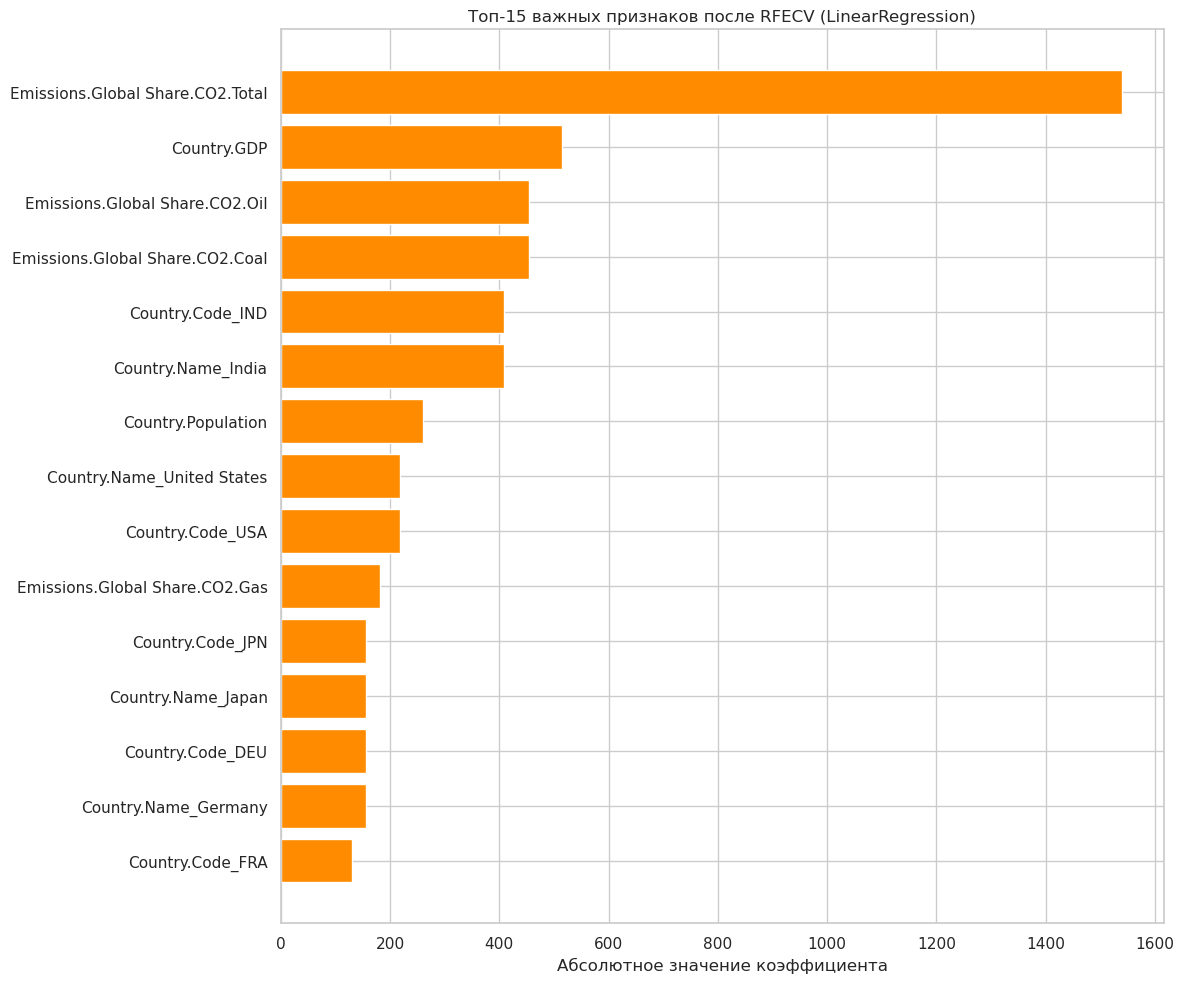

In [65]:
selected_features = [feature_names_full[i] for i in range(len(feature_names_full)) if rfecv.support_[i]]
coef_opt = lr_opt.coef_
imp_opt = pd.DataFrame({'feature': selected_features, 'importance': np.abs(coef_opt)})\
           .sort_values('importance', ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(imp_opt['feature'][-15:], imp_opt['importance'][-15:], color='darkorange')
plt.xlabel('Абсолютное значение коэффициента')
plt.title('Топ-15 важных признаков после RFECV (LinearRegression)')
plt.tight_layout()
plt.show()

## 8. Выводы

**Лучший регрессор без категориальных признаков (этап 1):**
- KNN: MSE: 1053.4966 MAE: 13.2853 R²: 0.9990

**Лучший регрессор с категориальными признаками (этап 2):**
- LinearRegression: MSE: 755.5260 MAE: 14.4165 R²: 0.9992

**Результаты фильтрации признаков:**

- После RFECV (LinearRegression): MSE: 755.5260 MAE: 14.4165 R²: 0.9992

- После SelectKBest (k=20): MSE: 1227.0463 MAE: 10.4864 R²: 0.9988

У обеих моделей результаты по каким-то метрикам ухудшились, по каким-то улучшились